# Ablation: Paraphrase Loss Weight (λ_para)

Comparing different paraphrase loss weights:
- **λ_para=0 (Default)**: No paraphrase loss (baseline)
- **λ_para=0.1**: Low paraphrase loss weight
- **λ_para=0.2**: Light weight
- **λ_para=0.3**: Medium-low weight
- **λ_para=0.5**: Medium weight

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
import numpy as np
from pathlib import Path

# Import shared ablation utilities
from ablation_utils import (
    setup_plotting_style,
    load_all_ablation_models,
    load_all_models_all_metrics,
    make_latex_ablation_table,
    plot_ablation_line,
    plot_ablation_bars,
    compute_deltas,
    print_summary,
    METRICS, METRIC_DISPLAY, METRIC_COLORS
)

# Set up plotting style
setup_plotting_style()

In [7]:
# =============================================================================
# CONFIGURATION - Define ablation models
# =============================================================================

ABLATION_MODELS = {
    "CS-CLIP (λ_para=0)": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "description": "No paraphrase loss (default)",
        "lambda_value": 0
    },
    "λ_para=0.1": {
        "csv_path": "../evaluation/ablations/16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.1.csv",
        "is_baseline": False,
        "description": "Low paraphrase loss weight",
        "lambda_value": 0.1
    },
    "λ_para=0.2": {
        "csv_path": "../evaluation/ablations/16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.2.csv",
        "is_baseline": False,
        "description": "Light weight",
        "lambda_value": 0.2
    },
    "λ_para=0.3": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.3.csv",
        "is_baseline": False,
        "description": "Medium-low weight",
        "lambda_value": 0.3
    },
    "λ_para=0.5": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.5.csv",
        "is_baseline": False,
        "description": "Medium weight",
        "lambda_value": 0.5
    },
}

# Primary metric for comparison
PRIMARY_METRIC = "text_contrastive_accuracy"

# Checkpoint selection (use best or specific step)
CHECKPOINT_STEP = None  # None = use best checkpoint, or specify step like 5000

# Ablation metadata
ABLATION_NAME = "PARAPHRASE LOSS WEIGHT ABLATION"
PARAM_KEY = "lambda_value"
PARAM_LABEL = r'$\lambda_{para}$'

print("Ablation: Paraphrase Loss Weight (λ_para)")
print("="*50)
for name, cfg in ABLATION_MODELS.items():
    baseline_mark = " [BASELINE]" if cfg["is_baseline"] else ""
    print(f"  {name}{baseline_mark}: {cfg['description']}")

Ablation: Paraphrase Loss Weight (λ_para)
  CS-CLIP (λ_para=0) [BASELINE]: No paraphrase loss (default)
  λ_para=0.1: Low paraphrase loss weight
  λ_para=0.2: Light weight
  λ_para=0.3: Medium-low weight
  λ_para=0.5: Medium weight


In [8]:
# =============================================================================
# LOAD DATA - Single Metric (Primary)
# =============================================================================

scores_df = load_all_ablation_models(ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP)
print(f"\nLoaded {len(scores_df)} models, {len(scores_df.columns)} datasets")

Loading CS-CLIP (λ_para=0)...
  Loaded 65 datasets (step=15000)
Loading λ_para=0.1...
  Loaded 65 datasets (step=20000)
Loading λ_para=0.2...
  Loaded 65 datasets (step=20000)
Loading λ_para=0.3...
  Loaded 65 datasets (step=20000)
Loading λ_para=0.5...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded 65 datasets (step=20000)

Common datasets (65): ['VL_CheckList/obj_location', 'VL_CheckList/attr_state', 'ColorFoil', 'VL_CheckList/obj_size', 'VL_CheckList/attr_size', 'VL_CheckList/attr_material', 'VL_CheckList/attr_action', 'VL_CheckList/rel_action', 'VL_CheckList/attr_color', 'VL_CheckList/rel_spatial', 'ControlledImages/A', 'SugarCrepe/add_obj', 'SPEC/relative_size', 'COCO_Order', 'Flickr30k_Order', 'NegBench/COCO_val_mcq_llama3.1_rephrased', 'SPEC/relative_spatial', 'VALSE/counting', 'SugarCrepe++/replace_attribute', 'SugarCrepe/swap_obj', 'ControlledImages/VG-Two', 'NegBench/msr_vtt_mcq_rephrased_llama', 'COLA/multi_objects', 'VALSE/existence', 'BLA/ap'

In [9]:
# =============================================================================
# DEBUG: Check which datasets/metrics are available in each file
# =============================================================================

import pandas as pd
from pathlib import Path

def debug_dataset_availability(models_config, target_metric="text_contrastive_accuracy"):
    """Check which datasets are available in each model's CSV and identify missing ones."""
    
    all_datasets_per_model = {}
    all_metrics_per_model = {}
    all_steps_per_model = {}
    
    for model_name, cfg in models_config.items():
        csv_path = Path(cfg['csv_path'])
        if not csv_path.exists():
            print(f"❌ {model_name}: FILE NOT FOUND - {csv_path}")
            continue
            
        df = pd.read_csv(csv_path)
        
        # Get unique datasets, metrics, and steps
        datasets = set(df['dataset'].unique())
        metrics = set(df['metric'].unique())
        steps = sorted(df['step'].unique())
        
        all_datasets_per_model[model_name] = datasets
        all_metrics_per_model[model_name] = metrics
        all_steps_per_model[model_name] = steps
        
        # Check if target metric exists
        has_target = target_metric in metrics
        
        print(f"\n{'='*60}")
        print(f"📁 {model_name}")
        print(f"   File: {csv_path.name}")
        print(f"   Steps: {steps}")
        print(f"   Datasets ({len(datasets)}): {sorted(datasets)}")
        print(f"   Metrics ({len(metrics)}): {sorted(metrics)}")
        print(f"   Has '{target_metric}': {'✅ Yes' if has_target else '❌ NO!'}")
        
        # Check VL_CheckList specifically
        if 'VL_CheckList' in datasets:
            vl_df = df[df['dataset'] == 'VL_CheckList']
            vl_metrics = set(vl_df['metric'].unique())
            vl_steps = sorted(vl_df['step'].unique())
            print(f"   VL_CheckList metrics: {sorted(vl_metrics)}")
            print(f"   VL_CheckList steps: {vl_steps}")
    
    # Find common datasets across all models
    if all_datasets_per_model:
        common_datasets = set.intersection(*all_datasets_per_model.values())
        all_datasets = set.union(*all_datasets_per_model.values())
        
        print(f"\n{'='*60}")
        print(f"📊 SUMMARY")
        print(f"{'='*60}")
        print(f"All datasets found: {sorted(all_datasets)}")
        print(f"Common datasets (in ALL models): {sorted(common_datasets)}")
        
        # Show which datasets are missing from which models
        missing_per_model = {}
        for model_name, datasets in all_datasets_per_model.items():
            missing = all_datasets - datasets
            if missing:
                missing_per_model[model_name] = missing
                
        if missing_per_model:
            print(f"\n⚠️  MISSING DATASETS:")
            for model_name, missing in missing_per_model.items():
                print(f"   {model_name}: missing {sorted(missing)}")
        else:
            print(f"\n✅ All models have the same datasets!")
            
        # Check metric availability
        print(f"\n📈 METRIC '{target_metric}' AVAILABILITY:")
        for model_name, metrics in all_metrics_per_model.items():
            if target_metric in metrics:
                print(f"   ✅ {model_name}")
            else:
                alt_metrics = [m for m in metrics if 'contrastive' in m.lower() or 'accuracy' in m.lower()]
                print(f"   ❌ {model_name} - has: {alt_metrics}")

# Run debug
debug_dataset_availability(ABLATION_MODELS, PRIMARY_METRIC)


📁 CS-CLIP (λ_para=0)
   File: 19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv
   Steps: [np.int64(0), np.int64(2500), np.int64(5000), np.int64(7500), np.int64(10000), np.int64(12500), np.int64(15000), np.int64(17500), np.int64(20000)]
   Datasets (20): ['BLA', 'CLIPBench', 'COCO_Counterfactuals', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC_I2T', 'SugarCrepe', 'SugarCrepe_PP', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']
   Metrics (90): ['Precision@1', 'Precision@1_GPU', 'acc1', 'acc5', 'accuracy', 'accuracy_caption1', 'accuracy_caption2', 'accuracy_overall', 'actions_group_contrastive_accuracy', 'ap_group_contrastive_accuracy', 'camera_perspective_group_contrastive_accuracy', 'camera_perspective_image_contrastive_accuracy', 'camera_perspective_text_contras

In [10]:
# =============================================================================
# DISPLAY RAW SCORES TABLE
# =============================================================================

# Convert to percentage and display
scores_pct = scores_df * 100

# Add average column
scores_pct['Average'] = scores_pct.mean(axis=1)

print("\n" + "="*60)
print(f"ABLATION: PARAPHRASE LOSS WEIGHT (λ_para)")
print(f"Metric: {PRIMARY_METRIC}")
print("="*60)
display(scores_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))


ABLATION: PARAPHRASE LOSS WEIGHT (λ_para)
Metric: text_contrastive_accuracy


,VL_CheckList/obj_location,VL_CheckList/attr_state,ColorFoil,VL_CheckList/obj_size,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/attr_color,VL_CheckList/rel_spatial,ControlledImages/A,SugarCrepe/add_obj,SPEC/relative_size,COCO_Order,Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,SPEC/relative_spatial,VALSE/counting,SugarCrepe++/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/ap,VisMin,BLA/co,BLA/rc,SPEC/count,VALSE/plurals,SugarCrepe/add_att,VG_Relation,Winoground,SugarCrepe++/replace_relation,VG_Attribution,COCO-CF,NegBench/VOC2007_mcq_llama3.1_rephrased,MMVP/Camera Perspective,MMVP/Color,SPEC/existence,VALSE/noun phrases,SugarCrepe++/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,VALSE/relations,MMVP/Quantity,MMVP/Spatial,MMVP/Orientation,MMVP/Presence,SugarCrepe/replace_att,SPEC/absolute_size,VALSE/actions,ControlledImages/B,ColorSwap,SugarCrepe++/swap_atribute,VALSE/coreference,SugarCrepe/replace_rel,SugarCrepe++/swap_object,ControlledImages/COCO-Two,SPEC/absolute_spatial,SugarCrepe/replace_obj,ControlledImages/COCO-One,MMVP/Text,MMVP/State,MMVP/Structural Character,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CS-CLIP (λ_para=0),94.100000,65.200000,90.500000,93.100000,64.300000,74.500000,78.100000,83.000000,79.200000,80.700000,29.100000,90.800000,32.700000,95.300000,96.700000,31.400000,29.500000,66.500000,74.200000,69.000000,53.100000,29.200000,41.000000,83.400000,52.700000,78.600000,48.400000,49.600000,34.500000,70.500000,80.800000,59.500000,29.800000,62.400000,70.000000,78.200000,37.800000,6.700000,13.300000,68.700000,93.700000,91.700000,74.500000,45.100000,70.100000,6.700000,46.700000,13.300000,0.000000,86.200000,38.800000,83.200000,34.600000,59.000000,56.500000,56.200000,79.700000,52.200000,50.900000,12.200000,94.900000,48.000000,13.300000,13.300000,6.700000,56.800000
λ_para=0.1,94.100000,64.500000,90.100000,93.100000,62.900000,75.600000,78.100000,83.300000,79.700000,79.000000,30.800000,89.700000,30.100000,95.900000,96.400000,32.700000,29.200000,66.800000,74.900000,71.400000,54.700000,30.400000,40.000000,82.400000,52.400000,78.300000,47.900000,49.300000,34.200000,71.200000,83.100000,59.500000,29.000000,62.800000,69.500000,77.800000,34.700000,13.300000,6.700000,71.600000,93.100000,91.000000,75.100000,44.100000,72.100000,6.700000,26.700000,13.300000,13.300000,86.700000,39.700000,82.700000,36.000000,58.300000,57.500000,57.800000,80.600000,53.100000,51.600000,12.100000,95.000000,48.900000,0.000000,6.700000,6.700000,56.600000
λ_para=0.2,94.200000,64.700000,89.900000,93.300000,63.800000,74.600000,78.100000,83.600000,79.400000,80.200000,30.300000,90.400000,32.500000,95.200000,96.900000,29.300000,29.600000,66.100000,74.000000,70.200000,55.400000,31.000000,38.100000,84.200000,53.300000,78.700000,47.400000,49.000000,35.000000,71.100000,80.300000,59.700000,28.500000,62.600000,69.200000,77.800000,35.600000,20.000000,13.300000,67.600000,93.200000,90.800000,74.500000,44.400000,70.700000,6.700000,33.300000,13.300000,13.300000,87.100000,38.400000,82.400000,34.800000,58.700000,58.600000,57.500000,80.600000,52.200000,51.800000,12.900000,94.700000,48.200000,0.000000,0.000000,6.700000,56.600000
λ_para=0.3,94.000000,64.800000,90.300000,93.100000,62.500000,74.200000,78.700000,82.200000,78.900000,78.300000,30.600000,90.300000,30.700000,94.900000,96.800000,30.600000,28.800000,66.400000,74.400000,69.800000,51.900000,30.400000,36.200000,82.600000,51.500000,77.500000,48.200000,49.200000,34.300000,70.900000,83.100000,59.400000,30.000000,62.700000,68.400000,78.400000,37.800000,13.300000,13.300000,68.700000,93.300000,91.200000,75.400000,46.300000,70.500000,13.300000,26.700000,20.000000,13.300000,87.300000,40.900000,82.900000,35.800000,59.300000,56.600000,59.100000,80.000000,52.200000,50.900000,12.600000,95.000000,49.700000,6.700000,6.70000

In [11]:
# =============================================================================
# LOAD ALL METRICS (Text, Image, Group Contrastive Accuracy)
# =============================================================================

# Load all models with all metrics
all_metrics_df = load_all_models_all_metrics(ABLATION_MODELS, METRICS, CHECKPOINT_STEP)

# Extract just the summary columns (I2T, T2I, Group)
summary_cols = [col for col in ['I2T', 'T2I', 'Group'] if col in all_metrics_df.columns]
summary_df = all_metrics_df[summary_cols].copy()

# Add overall average
summary_df['Average'] = summary_df.mean(axis=1)

print("\n" + "="*60)
print("ABLATION: PARAPHRASE LOSS WEIGHT - ALL METRICS")
print("="*60)
display((summary_df * 100).round(1).style.highlight_max(axis=0, color='lightgreen'))

Loading CS-CLIP (λ_para=0)...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_para=0.1...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_para=0.2...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_para=0.3...
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading λ_para=0.5...
[apply_mappings] Dropped 5 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']

ABLATION: PARAPHRASE LOSS WEIGHT - ALL METRICS


,I2T,T2I,Group,Average
Model,,,,
CS-CLIP (λ_para=0),62.000000,41.600000,25.400000,43.000000
λ_para=0.1,61.700000,40.900000,24.900000,42.500000
λ_para=0.2,61.600000,40.100000,24.200000,42.000000
λ_para=0.3,61.700000,40.700000,25.000000,42.400000
λ_para=0.5,61.600000,40.900000,25.100000,42.500000


In [12]:
# =============================================================================
# LATEX TABLE GENERATION
# =============================================================================

# Generate LaTeX table
latex_table = make_latex_ablation_table(
    summary_df,
    ABLATION_MODELS,
    caption="Paraphrase loss weight ($\\lambda_{\\text{para}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \\textbf{bold}, baseline \\underline{underlined}.",
    label="tab:ablation_paraphrase_lambda",
)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(latex_table)

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Paraphrase loss weight ($\lambda_{\text{para}}$) ablation. I2T = Image-to-Text, T2I = Text-to-Image, Group = both correct. Best in \textbf{bold}, baseline \underline{underlined}.}
  \label{tab:ablation_paraphrase_lambda}
  \begin{tabular}{lcccc}
    \toprule
    Model & I2T & T2I & Group & Average \\
    \midrule
    CS-CLIP (λ\_para=0) & \textbf{\underline{62.0}} & \textbf{\underline{41.6}} & \textbf{\underline{25.4}} & \textbf{\underline{43.0}} \\
    λ\_para=0.1 & 61.7 & 40.9 & 24.9 & 42.5 \\
    λ\_para=0.2 & 61.6 & 40.1 & 24.2 & 42.0 \\
    λ\_para=0.3 & 61.7 & 40.7 & 25.0 & 42.4 \\
    λ\_para=0.5 & 61.6 & 40.9 & 25.1 & 42.5 \\
    \bottomrule
  \end{tabular}
\end{table}


In [13]:
# =============================================================================
# VISUALIZATION: LINE PLOT (λ vs Performance)
# =============================================================================

# Extract lambda values and corresponding scores
lambda_values = [ABLATION_MODELS[model]['lambda_value'] for model in summary_df.index]

fig, ax = plot_ablation_line(
    summary_df,
    lambda_values,
    ABLATION_MODELS,
    param_label=PARAM_LABEL,
    title='Paraphrase Loss Weight Ablation',
    save_path='../paper_figures/ablation_paraphrase_lambda_line.pdf'
)

TypeError: list indices must be integers or slices, not str

Saved: ../paper_figures/ablation_paraphrase_lambda_bars.pdf


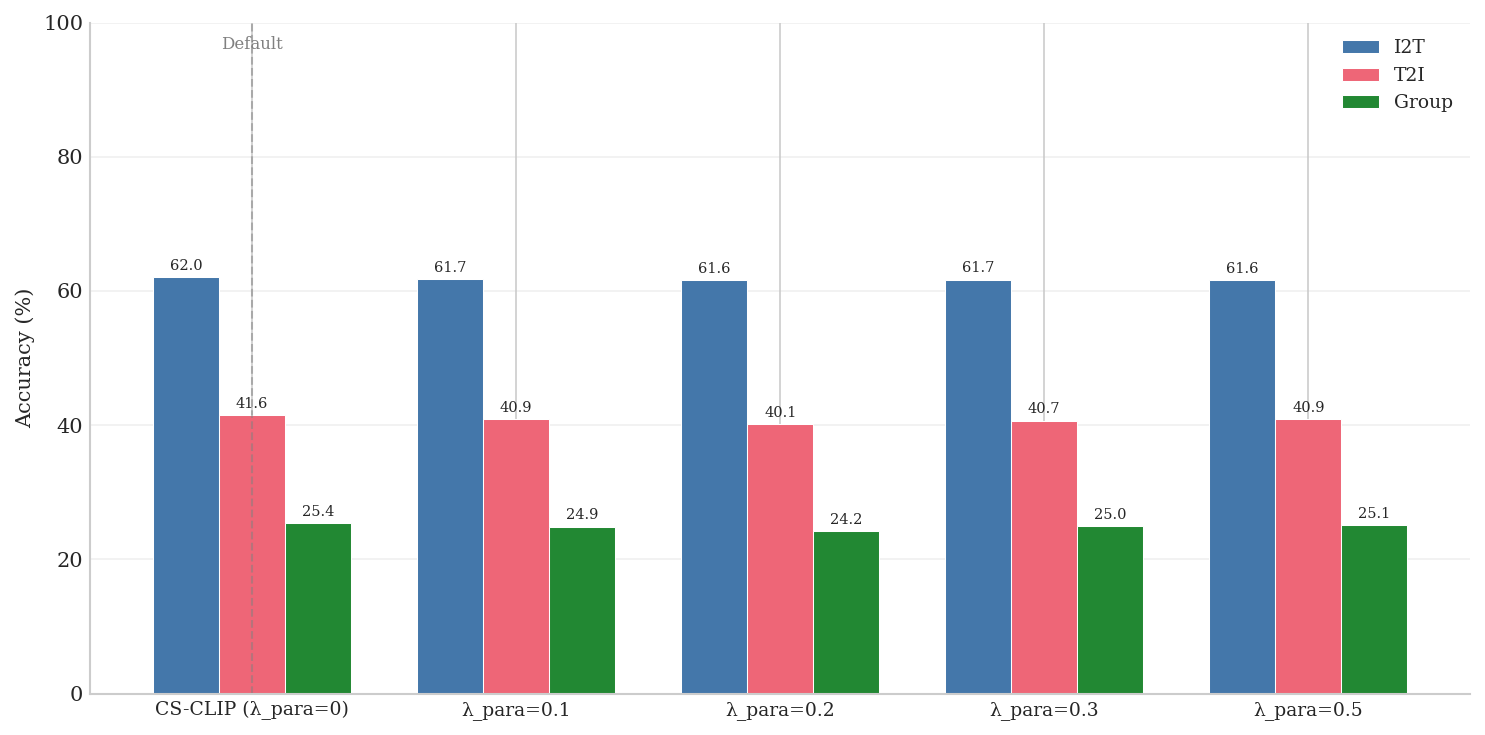

In [14]:
# =============================================================================
# VISUALIZATION: GROUPED BAR CHART (All Metrics)
# =============================================================================

fig, ax = plot_ablation_bars(
    summary_df,
    ABLATION_MODELS,
    title='Paraphrase Loss Weight Ablation',
    save_path='../paper_figures/ablation_paraphrase_lambda_bars.pdf'
)

In [15]:
# =============================================================================
# COMPUTE DELTAS FROM BASELINE
# =============================================================================

deltas_df = compute_deltas(summary_df, ABLATION_MODELS)

print("\n" + "="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)
display(deltas_df.round(2).style.background_gradient(cmap='RdYlGn', axis=None))


DELTA FROM BASELINE (percentage points)


,I2T,T2I,Group,Average
Model,,,,
CS-CLIP (λ_para=0),0.000000,0.000000,0.000000,0.000000
λ_para=0.1,-0.260000,-0.660000,-0.540000,-0.480000
λ_para=0.2,-0.380000,-1.430000,-1.200000,-1.000000
λ_para=0.3,-0.320000,-0.880000,-0.430000,-0.550000
λ_para=0.5,-0.380000,-0.670000,-0.330000,-0.460000


In [16]:
# =============================================================================
# SUMMARY
# =============================================================================

print_summary(summary_df, ABLATION_MODELS, ABLATION_NAME, PARAM_KEY)


SUMMARY: PARAPHRASE LOSS WEIGHT ABLATION

Baseline: CS-CLIP (λ_para=0)

Average Performance:
  ★ CS-CLIP (λ_para=0): 43.0% (+0.00pp vs baseline) | lambda_value=0
    λ_para=0.1: 42.5% (-0.48pp vs baseline) | lambda_value=0.1
    λ_para=0.2: 42.0% (-1.00pp vs baseline) | lambda_value=0.2
    λ_para=0.3: 42.4% (-0.55pp vs baseline) | lambda_value=0.3
    λ_para=0.5: 42.5% (-0.46pp vs baseline) | lambda_value=0.5

Key Findings:
  - Best: CS-CLIP (λ_para=0) (43.0%)
  - Worst: λ_para=0.2 (42.0%)
  - Gap: 1.0pp


In [17]:
# =============================================================================
# DATASET-WISE AND SUBSET-WISE TABLES (with ARO merging)
# =============================================================================

from ablation_utils import (
    load_all_models_per_dataset,
    load_all_models_per_subset,
    make_latex_dataset_table,
    get_datasets_and_subsets,
    display_all_tables,
    load_benchmark_config
)

# Load benchmark config for dataset merge rules (e.g., ARO)
bench_cfg = load_benchmark_config()

# Display all tables for the primary metric (I2T) with ARO merging
dataset_df, subset_df, datasets_subsets = display_all_tables(
    ABLATION_MODELS, PRIMARY_METRIC, CHECKPOINT_STEP, 
    show_latex=True, apply_merge=True, benchmark_config=bench_cfg
)


PER-DATASET RESULTS (I2T)
[apply_mappings] Dropped 5 original rows replaced by aliased metrics


,ARO,BLA,COCO-CF,COLA,ColorFoil,ColorSwap,ControlledImages,MMVP,NegBench,SPEC,SugarCrepe,SugarCrepe++,VALSE,VL_CheckList,VisMin,Winoground,Average
Model,,,,,,,,,,,,,,,,,
CS-CLIP (λ_para=0),80.400000,50.200000,78.200000,41.000000,90.500000,59.000000,43.500000,13.300000,32.800000,36.100000,82.200000,67.400000,74.800000,79.200000,78.600000,29.800000,58.600000
λ_para=0.1,80.300000,49.900000,77.800000,40.000000,90.100000,58.300000,44.400000,10.400000,32.600000,36.200000,83.100000,67.800000,75.200000,78.900000,78.300000,29.000000,58.300000
λ_para=0.2,80.300000,49.900000,77.800000,38.100000,89.900000,58.700000,44.200000,11.900000,32.000000,36.000000,82.500000,67.600000,75.000000,79.100000,78.700000,28.500000,58.100000
λ_para=0.3,79.800000,49.600000,78.400000,36.200000,90.300000,59.300000,44.200000,14.100000,32.900000,36.000000,83.000000,67.400000,75.100000,78.500000,77.500000,30.000000,58.300000
λ_para=0.5,80.100000,49.600000,77.700000,38.600000,88.600000,60.000000,43.600000,10.400000,32.600000,35.500000,83.100000,67.900000,75.600000,78.900000,78.200000,30.200000,58.200000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-dataset I2T accuracy.}
  \label{tab:ablation_datasets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{ARO} & \rotatebox{60}{BLA} & \rotatebox{60}{COCO-CF} & \rotatebox{60}{COLA} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{ColorSwap} & \rotatebox{60}{ControlledImages} & \rotatebox{60}{MMVP} & \rotatebox{60}{NegBench} & \rotatebox{60}{SPEC} & \rotatebox{60}{SugarCrepe} & \rotatebox{60}{SugarCrepe++} & \rotatebox{60}{VALSE} & \rotatebox{60}{VL\_CheckList} & \rotatebox{60}{VisMin} & \rotatebox{60}{Winoground} & \rotatebox{60}{Avg} \\
    \midrule
    CS-CLIP (λ\_para=0) & \textbf{\underline{80.4}} & \textbf{\underline{50.2}} & \underline{78.2} & \textbf{\underline{41.0}} & \textbf{\underline{90.5}} & \underline{59.0} & \underline{43.5} & \underline{13.3} & \underline{32.8} & \underline{36.1} & \underline{82.2} & \underline{67.4} & \underline{74.8}

,VL_CheckList/obj_location,VL_CheckList/attr_state,ColorFoil,VL_CheckList/obj_size,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/attr_color,VL_CheckList/rel_spatial,ControlledImages/A,SugarCrepe/add_obj,SPEC/relative_size,ARO/COCO_Order,ARO/Flickr30k_Order,NegBench/COCO_val_mcq_llama3.1_rephrased,SPEC/relative_spatial,VALSE/counting,SugarCrepe++/replace_attribute,SugarCrepe/swap_obj,ControlledImages/VG-Two,NegBench/msr_vtt_mcq_rephrased_llama,COLA/multi_objects,VALSE/existence,BLA/ap,VisMin,BLA/co,BLA/rc,SPEC/count,VALSE/plurals,SugarCrepe/add_att,ARO/VG_Relation,Winoground,SugarCrepe++/replace_relation,ARO/VG_Attribution,COCO-CF,NegBench/VOC2007_mcq_llama3.1_rephrased,MMVP/Camera Perspective,MMVP/Color,SPEC/existence,VALSE/noun phrases,SugarCrepe++/replace_object,SugarCrepe/swap_att,ControlledImages/VG-One,VALSE/relations,MMVP/Quantity,MMVP/Spatial,MMVP/Orientation,MMVP/Presence,SugarCrepe/replace_att,SPEC/absolute_size,VALSE/actions,ControlledImages/B,ColorSwap,SugarCrepe++/swap_atribute,VALSE/coreference,SugarCrepe/replace_rel,SugarCrepe++/swap_object,ControlledImages/COCO-Two,SPEC/absolute_spatial,SugarCrepe/replace_obj,ControlledImages/COCO-One,MMVP/Text,MMVP/State,MMVP/Structural Character,Average
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CS-CLIP (λ_para=0),94.100000,65.200000,90.500000,93.100000,64.300000,74.500000,78.100000,83.000000,79.200000,80.700000,29.100000,90.800000,32.700000,95.300000,96.700000,31.400000,29.500000,66.500000,74.200000,69.000000,53.100000,29.200000,41.000000,83.400000,52.700000,78.600000,48.400000,49.600000,34.500000,70.500000,80.800000,59.500000,29.800000,62.400000,70.000000,78.200000,37.800000,6.700000,13.300000,68.700000,93.700000,91.700000,74.500000,45.100000,70.100000,6.700000,46.700000,13.300000,0.000000,86.200000,38.800000,83.200000,34.600000,59.000000,56.500000,56.200000,79.700000,52.200000,50.900000,12.200000,94.900000,48.000000,13.300000,13.300000,6.700000,56.800000
λ_para=0.1,94.100000,64.500000,90.100000,93.100000,62.900000,75.600000,78.100000,83.300000,79.700000,79.000000,30.800000,89.700000,30.100000,95.900000,96.400000,32.700000,29.200000,66.800000,74.900000,71.400000,54.700000,30.400000,40.000000,82.400000,52.400000,78.300000,47.900000,49.300000,34.200000,71.200000,83.100000,59.500000,29.000000,62.800000,69.500000,77.800000,34.700000,13.300000,6.700000,71.600000,93.100000,91.000000,75.100000,44.100000,72.100000,6.700000,26.700000,13.300000,13.300000,86.700000,39.700000,82.700000,36.000000,58.300000,57.500000,57.800000,80.600000,53.100000,51.600000,12.100000,95.000000,48.900000,0.000000,6.700000,6.700000,56.600000
λ_para=0.2,94.200000,64.700000,89.900000,93.300000,63.800000,74.600000,78.100000,83.600000,79.400000,80.200000,30.300000,90.400000,32.500000,95.200000,96.900000,29.300000,29.600000,66.100000,74.000000,70.200000,55.400000,31.000000,38.100000,84.200000,53.300000,78.700000,47.400000,49.000000,35.000000,71.100000,80.300000,59.700000,28.500000,62.600000,69.200000,77.800000,35.600000,20.000000,13.300000,67.600000,93.200000,90.800000,74.500000,44.400000,70.700000,6.700000,33.300000,13.300000,13.300000,87.100000,38.400000,82.400000,34.800000,58.700000,58.600000,57.500000,80.600000,52.200000,51.800000,12.900000,94.700000,48.200000,0.000000,0.000000,6.700000,56.600000
λ_para=0.3,94.000000,64.800000,90.300000,93.100000,62.500000,74.200000,78.700000,82.200000,78.900000,78.300000,30.600000,90.300000,30.700000,94.900000,96.800000,30.600000,28.800000,66.400000,74.400000,69.800000,51.900000,30.400000,36.200000,82.600000,51.500000,77.500000,48.200000,49.200000,34.300000,70.900000,83.100000,59.400000,30.000000,62.700000,68.400000,78.400000,37.800000,13.300000,13.300000,68.700000,93.300000,91.200000,75.400000,46.300000,70.500000,13.300000,26.700000,20.000000,13.300000,87.300000,40.900000,82.900000,35.800000,59.300000,56.600000,59.100000,80.000000,52.200000,50.900000,12.600000,95.000000,49.700000,


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{Per-subset I2T accuracy.}
  \label{tab:ablation_subsets_i2t}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc}
    \toprule
    Model & \rotatebox{60}{VL\_CheckList/obj\_location} & \rotatebox{60}{VL\_CheckList/attr\_state} & \rotatebox{60}{ColorFoil} & \rotatebox{60}{VL\_CheckList/obj\_size} & \rotatebox{60}{VL\_CheckList/attr\_size} & \rotatebox{60}{VL\_CheckList/attr\_material} & \rotatebox{60}{VL\_CheckList/attr\_action} & \rotatebox{60}{VL\_CheckList/rel\_action} & \rotatebox{60}{VL\_CheckList/attr\_color} & \rotatebox{60}{VL\_CheckList/rel\_spatial} & \rotatebox{60}{ControlledImages/A} & \rotatebox{60}{SugarCrepe/add\_obj} & \rotatebox{60}{SPEC/relative\_size} & \rotatebox{60}{ARO/COCO\_Order} & \rotatebox{60}{ARO/Flickr30k\_Order} & \rotatebox{60}{NegBench/COCO\_val\_mcq\_llama3.1\_rephrased} & \rotatebox{60}{SPEC/relative\_spatial} & \rot

In [18]:
# =============================================================================
# PER-DATASET LATEX TABLE (for specific datasets with subsets)
# =============================================================================

# Generate separate tables for datasets with multiple subsets
for dataset_name, subsets in sorted(datasets_subsets.items()):
    if len(subsets) > 1:  # Only show datasets with multiple subsets
        print(f"\n{'='*60}")
        print(f"DATASET: {dataset_name} (subsets: {subsets})")
        print("="*60)
        
        # Filter subset_df to only this dataset
        cols = [c for c in subset_df.columns if c.startswith(f"{dataset_name}/") or c == dataset_name]
        if cols:
            ds_df = subset_df[cols]
            ds_pct = ds_df * 100
            ds_pct['Avg'] = ds_pct.mean(axis=1)
            display(ds_pct.round(1).style.highlight_max(axis=0, color='lightgreen'))
            
            # LaTeX
            print("\nLaTeX:")
            print(make_latex_dataset_table(
                ds_df, ABLATION_MODELS,
                caption=f"{dataset_name} subset breakdown (I2T accuracy).",
                label=f"tab:ablation_{dataset_name.lower()}_subsets",
                rotate_headers=False
            ))


DATASET: ARO (subsets: ['COCO_Order', 'Flickr30k_Order', 'VG_Attribution', 'VG_Relation'])


,ARO/COCO_Order,ARO/Flickr30k_Order,ARO/VG_Relation,ARO/VG_Attribution,Avg
Model,,,,,
CS-CLIP (λ_para=0),95.300000,96.700000,59.500000,70.000000,80.400000
λ_para=0.1,95.900000,96.400000,59.500000,69.500000,80.300000
λ_para=0.2,95.200000,96.900000,59.700000,69.200000,80.300000
λ_para=0.3,94.900000,96.800000,59.400000,68.400000,79.800000
λ_para=0.5,94.800000,96.700000,59.600000,69.300000,80.100000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{ARO subset breakdown (I2T accuracy).}
  \label{tab:ablation_aro_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lccccc}
    \toprule
    Model & ARO/COCO\_Order & ARO/Flickr30k\_Order & ARO/VG\_Relation & ARO/VG\_Attribution & Avg \\
    \midrule
    CS-CLIP (λ\_para=0) & \underline{95.3} & \underline{96.7} & \underline{59.5} & \textbf{\underline{70.0}} & \textbf{\underline{80.4}} \\
    λ\_para=0.1 & \textbf{95.9} & 96.4 & 59.5 & 69.5 & 80.3 \\
    λ\_para=0.2 & 95.2 & \textbf{96.9} & \textbf{59.7} & 69.2 & 80.3 \\
    λ\_para=0.3 & 94.9 & 96.8 & 59.4 & 68.4 & 79.8 \\
    λ\_para=0.5 & 94.8 & 96.7 & 59.6 & 69.3 & 80.1 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: BLA (subsets: ['ap', 'co', 'rc'])


,BLA/ap,BLA/co,BLA/rc,Avg
Model,,,,
CS-CLIP (λ_para=0),52.700000,48.400000,49.600000,50.200000
λ_para=0.1,52.400000,47.900000,49.300000,49.900000
λ_para=0.2,53.300000,47.400000,49.000000,49.900000
λ_para=0.3,51.500000,48.200000,49.200000,49.600000
λ_para=0.5,50.700000,48.200000,49.700000,49.600000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{BLA subset breakdown (I2T accuracy).}
  \label{tab:ablation_bla_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccc}
    \toprule
    Model & BLA/ap & BLA/co & BLA/rc & Avg \\
    \midrule
    CS-CLIP (λ\_para=0) & \underline{52.7} & \textbf{\underline{48.4}} & \underline{49.6} & \textbf{\underline{50.2}} \\
    λ\_para=0.1 & 52.4 & 47.9 & 49.3 & 49.9 \\
    λ\_para=0.2 & \textbf{53.3} & 47.4 & 49.0 & 49.9 \\
    λ\_para=0.3 & 51.5 & 48.2 & 49.2 & 49.6 \\
    λ\_para=0.5 & 50.7 & 48.2 & \textbf{49.7} & 49.6 \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: ControlledImages (subsets: ['A', 'B', 'COCO-One', 'COCO-Two', 'VG-One', 'VG-Two'])


...


LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{SugarCrepe++ subset breakdown (I2T accuracy).}
  \label{tab:ablation_sugarcrepe++_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccc}
    \toprule
    Model & SugarCrepe++/replace\_attribute & SugarCrepe++/replace\_relation & SugarCrepe++/replace\_object & SugarCrepe++/swap\_atribute & SugarCrepe++/swap\_object & Avg \\
    \midrule
    CS-CLIP (λ\_para=0) & \underline{74.2} & \underline{62.4} & \textbf{\underline{91.7}} & \underline{56.5} & \underline{52.2} & \underline{67.4} \\
    λ\_para=0.1 & \textbf{74.9} & 62.8 & 91.0 & 57.5 & \textbf{53.1} & 67.8 \\
    λ\_para=0.2 & 74.0 & 62.6 & 90.8 & \textbf{58.6} & 52.2 & 67.6 \\
    λ\_para=0.3 & 74.4 & 62.7 & 91.2 & 56.6 & 52.2 & 67.4 \\
    λ\_para=0.5 & 74.9 & \textbf{64.1} & 91.0 & 57.5 & 51.8 & \textbf{67.9} \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATASET: VALSE (subsets: ['actions', 'coreference', 'counting', 'existence

,VALSE/counting,VALSE/existence,VALSE/plurals,VALSE/noun phrases,VALSE/relations,VALSE/actions,VALSE/coreference,Avg
Model,,,,,,,,
CS-CLIP (λ_para=0),66.500000,83.400000,70.500000,93.700000,70.100000,83.200000,56.200000,74.800000
λ_para=0.1,66.800000,82.400000,71.200000,93.100000,72.100000,82.700000,57.800000,75.200000
λ_para=0.2,66.100000,84.200000,71.100000,93.200000,70.700000,82.400000,57.500000,75.000000
λ_para=0.3,66.400000,82.600000,70.900000,93.300000,70.500000,82.900000,59.100000,75.100000
λ_para=0.5,66.900000,84.800000,71.600000,94.000000,71.800000,83.900000,56.700000,75.600000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VALSE subset breakdown (I2T accuracy).}
  \label{tab:ablation_valse_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccc}
    \toprule
    Model & VALSE/counting & VALSE/existence & VALSE/plurals & VALSE/noun phrases & VALSE/relations & VALSE/actions & VALSE/coreference & Avg \\
    \midrule
    CS-CLIP (λ\_para=0) & \underline{66.5} & \underline{83.4} & \underline{70.5} & \underline{93.7} & \underline{70.1} & \underline{83.2} & \underline{56.2} & \underline{74.8} \\
    λ\_para=0.1 & 66.8 & 82.4 & 71.2 & 93.1 & \textbf{72.1} & 82.7 & 57.8 & 75.2 \\
    λ\_para=0.2 & 66.1 & 84.2 & 71.1 & 93.2 & 70.7 & 82.4 & 57.5 & 75.0 \\
    λ\_para=0.3 & 66.4 & 82.6 & 70.9 & 93.3 & 70.5 & 82.9 & \textbf{59.1} & 75.1 \\
    λ\_para=0.5 & \textbf{66.9} & \textbf{84.8} & \textbf{71.6} & \textbf{94.0} & 71.8 & \textbf{83.9} & 56.7 & \textbf{75.6} \\
    \bottomrule
  \end{tabular}
  \end{adjustbox}
\end{table}

DATA

,VL_CheckList/obj_location,VL_CheckList/attr_state,VL_CheckList/obj_size,VL_CheckList/attr_size,VL_CheckList/attr_material,VL_CheckList/attr_action,VL_CheckList/rel_action,VL_CheckList/attr_color,VL_CheckList/rel_spatial,Avg
Model,,,,,,,,,,
CS-CLIP (λ_para=0),94.100000,65.200000,93.100000,64.300000,74.500000,78.100000,83.000000,79.200000,80.700000,79.200000
λ_para=0.1,94.100000,64.500000,93.100000,62.900000,75.600000,78.100000,83.300000,79.700000,79.000000,78.900000
λ_para=0.2,94.200000,64.700000,93.300000,63.800000,74.600000,78.100000,83.600000,79.400000,80.200000,79.100000
λ_para=0.3,94.000000,64.800000,93.100000,62.500000,74.200000,78.700000,82.200000,78.900000,78.300000,78.500000
λ_para=0.5,94.200000,65.000000,93.400000,63.700000,74.700000,77.600000,83.200000,79.200000,79.300000,78.900000



LaTeX:
\begin{table}[t]
  \centering
  \scriptsize
  \caption{VL_CheckList subset breakdown (I2T accuracy).}
  \label{tab:ablation_vl_checklist_subsets}
  \begin{adjustbox}{max width=\textwidth}
  \begin{tabular}{lcccccccccc}
    \toprule
    Model & VL\_CheckList/obj\_location & VL\_CheckList/attr\_state & VL\_CheckList/obj\_size & VL\_CheckList/attr\_size & VL\_CheckList/attr\_material & VL\_CheckList/attr\_action & VL\_CheckList/rel\_action & VL\_CheckList/attr\_color & VL\_CheckList/rel\_spatial & Avg \\
    \midrule
    CS-CLIP (λ\_para=0) & \underline{94.1} & \textbf{\underline{65.2}} & \underline{93.1} & \textbf{\underline{64.3}} & \underline{74.5} & \underline{78.1} & \underline{83.0} & \underline{79.2} & \textbf{\underline{80.7}} & \textbf{\underline{79.2}} \\
    λ\_para=0.1 & 94.1 & 64.5 & 93.1 & 62.9 & \textbf{75.6} & 78.1 & 83.3 & \textbf{79.7} & 79.0 & 78.9 \\
    λ\_para=0.2 & 94.2 & 64.7 & 93.3 & 63.8 & 74.6 & 78.1 & \textbf{83.6} & 79.4 & 80.2 & 79.1 \\
    λ\_para=0.